<a href="https://colab.research.google.com/github/Lochan9866/Machine_Learning_Projects/blob/main/Diabete_Predictio_Using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 0. Upload the CSV (Colab only)
# -----------------------------
from google.colab import files
uploaded = files.upload()  # choose diabetes.csv when prompted

Saving diabetes.csv to diabetes (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib

## 1. Load Data

In [5]:
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
display(df.head())
print(df.info())
display(df.describe())

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Basic EDA

In [6]:
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["Outcome"].value_counts())


Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


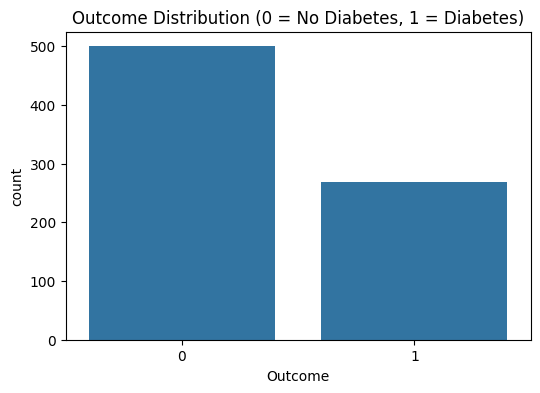

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Outcome Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

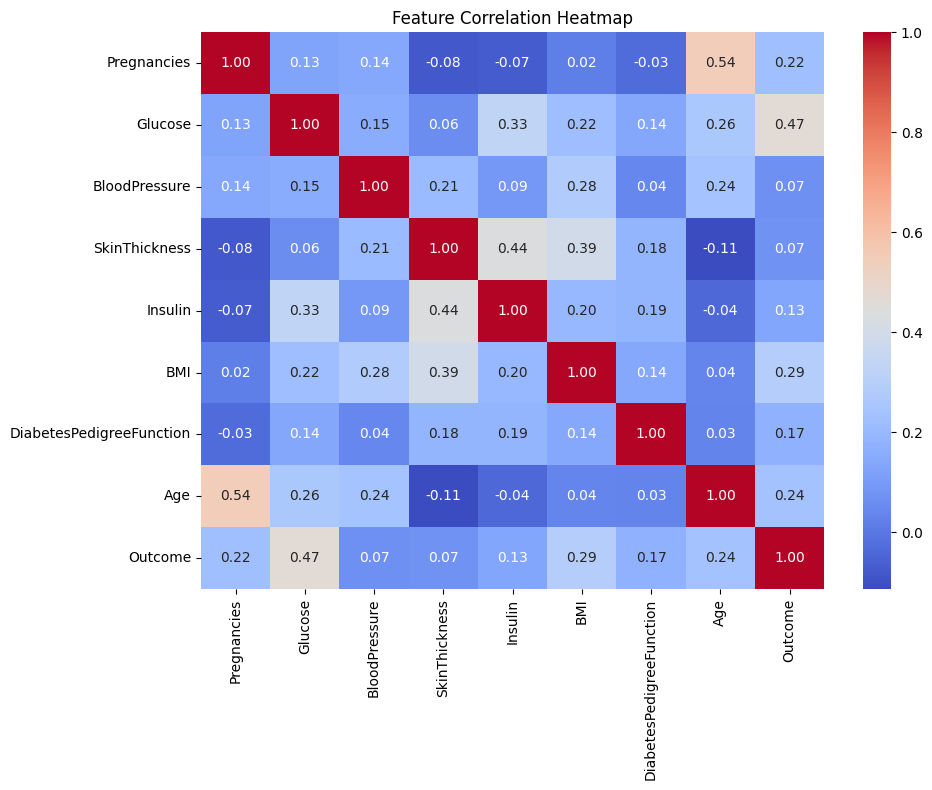

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

** Histograms of all features

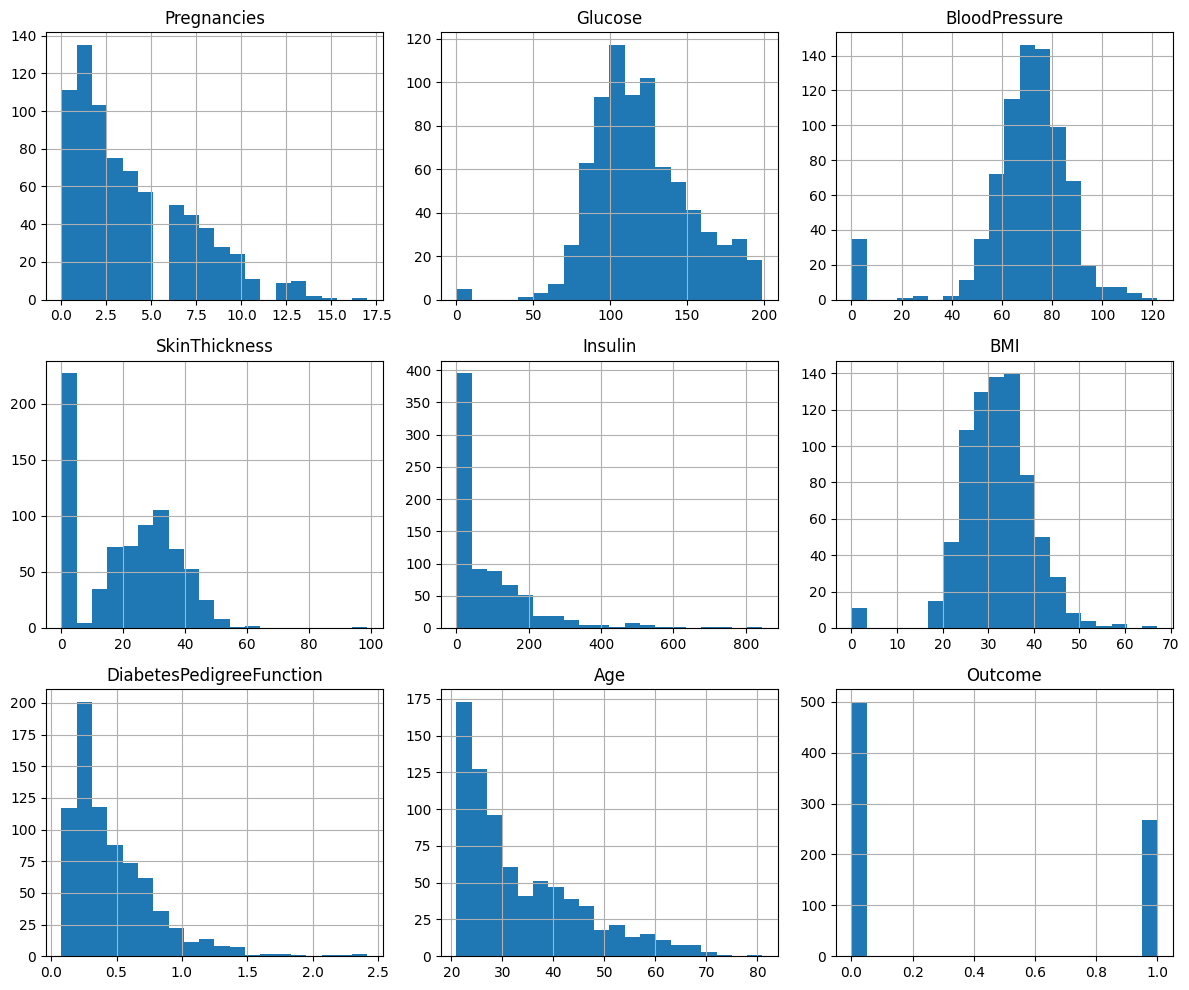

In [9]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [10]:
# 0 is not biologically valid for these columns -> treat as missing, impute with median
cols_with_invalid_zero = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
for col in cols_with_invalid_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

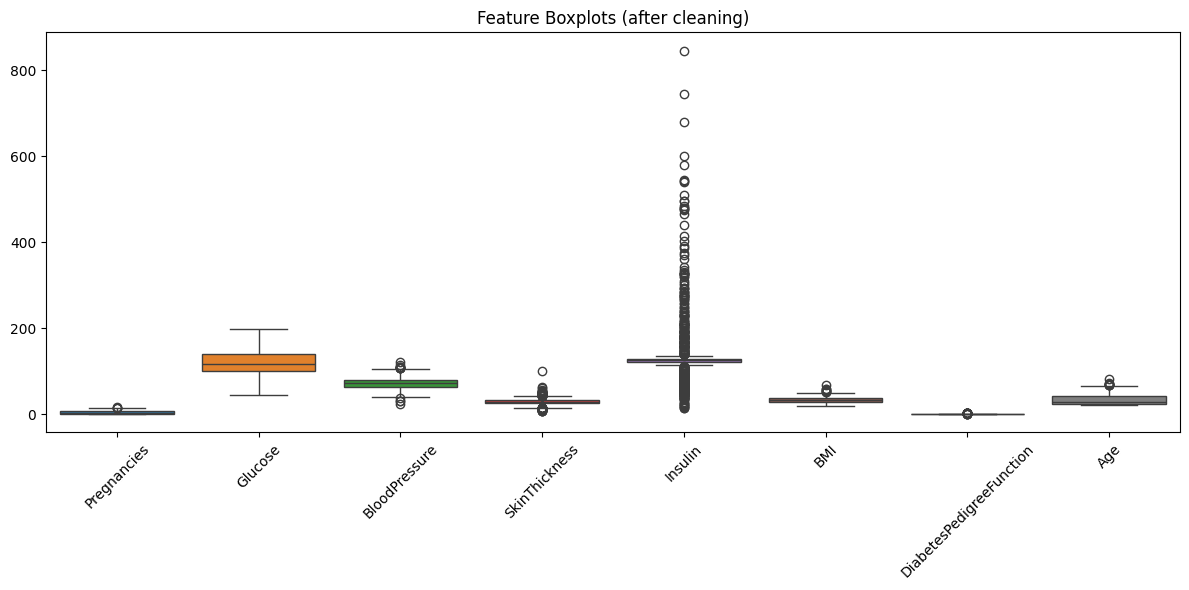

In [11]:
# Boxplots after cleaning (check outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop("Outcome", axis=1))
plt.xticks(rotation=45)
plt.title("Feature Boxplots (after cleaning)")
plt.tight_layout()
plt.show()

## 4. Feature / Target Split

In [12]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train Multiple Models

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

results = {}

In [15]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "model": model, "accuracy": acc, "precision": prec,
        "recall": rec, "f1": f1, "roc_auc": auc,
    }

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1 Score : 0.5455
ROC-AUC  : 0.8130
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


===== Random Forest =====
Accuracy : 0.7403
Precision: 0.6522
Recall   : 0.5556
F1 Score : 0.6000
ROC-AUC  : 0.8161
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


===== SVM =====
Accuracy : 0.7403
Precision: 0.6522
Recall   : 0.5556
F1 Score : 0.6000
ROC-AUC  : 0.7964

## 7. Compare Models Bar chart


Model Comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
KNN,0.740260,0.634615,0.611111,0.622642,0.795093
SVM,0.740260,0.652174,0.555556,0.600000,0.796389
Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
Decision Tree,0.681818,0.553191,0.481481,0.514851,0.635741


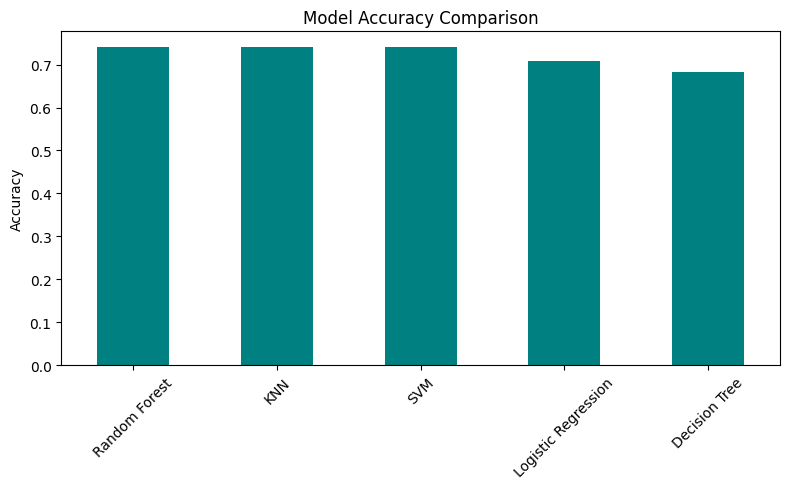


Best model: Random Forest


In [16]:
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"], "Precision": res["precision"],
        "Recall": res["recall"], "F1": res["f1"], "ROC-AUC": res["roc_auc"],
    }
    for name, res in results.items()
}).T.sort_values("Accuracy", ascending=False)

print("\nModel Comparison:")
display(comparison_df)

comparison_df["Accuracy"].plot(kind="bar", figsize=(8, 5), color="teal")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.index[0]
best_model = results[best_model_name]["model"]
print(f"\nBest model: {best_model_name}")

## 8.Confusion Matrix for Best Models

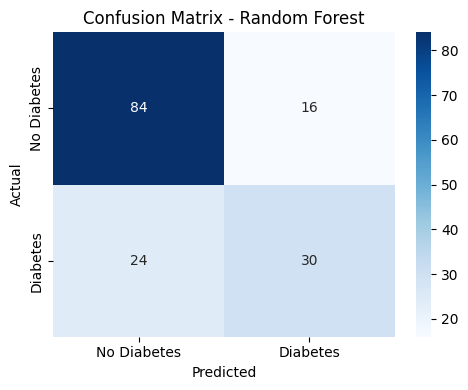

In [17]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 9. ROC curves for all Models

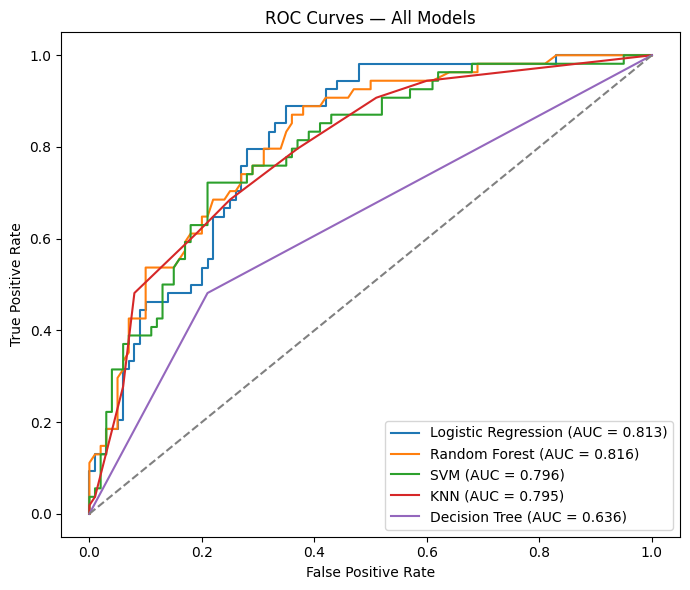

In [18]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    proba = res["model"].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Feature Importance

/tmp/ipykernel_721/1865941217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


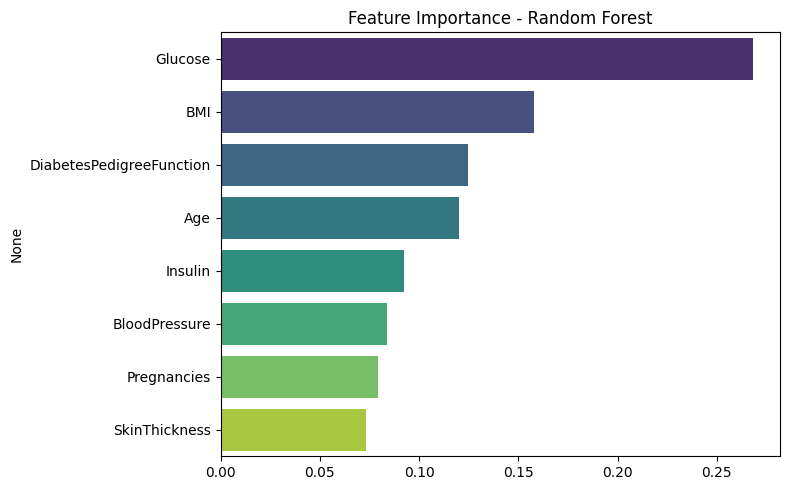


Feature Importance:
 Glucose                     0.268355
BMI                         0.158066
DiabetesPedigreeFunction    0.124386
Age                         0.120345
Insulin                     0.092340
BloodPressure               0.083938
Pregnancies                 0.079370
SkinThickness               0.073200
dtype: float64


In [19]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()
    print("\nFeature Importance:\n", importances)

## 11. Hyperparameter Tuning ( Random Forest Example )

In [20]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("\nBest params (Random Forest):", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test_scaled)
print("Tuned Random Forest test accuracy:", accuracy_score(y_test, tuned_pred))


Best params (Random Forest): {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best CV accuracy: 0.7736505397840864
Tuned Random Forest test accuracy: 0.7597402597402597


## 12. Save Best Models and Scalar (Downloads in Colab)

In [23]:
joblib.dump(best_model, "best_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print(f"\nSaved '{best_model_name}' model to best_diabetes_model.pkl")
print("Saved scaler to scaler.pkl")

# Uncomment to download the files from Colab to your computer:
#files.download("best_diabetes_model.pkl")
#files.download("scaler.pkl")


Saved 'Random Forest' model to best_diabetes_model.pkl
Saved scaler to scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13.Predict on New Data ( Example )

In [22]:
def predict_diabetes(input_dict, model=best_model, scaler=scaler):
    """
    input_dict example:
    {
        "Pregnancies": 2, "Glucose": 130, "BloodPressure": 70,
        "SkinThickness": 20, "Insulin": 85, "BMI": 28.5,
        "DiabetesPedigreeFunction": 0.4, "Age": 33
    }
    """
    input_df = pd.DataFrame([input_dict])
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]
    return {
        "prediction": "Diabetic" if prediction == 1 else "Not Diabetic",
        "probability": round(float(probability), 4),
    }

sample = {
    "Pregnancies": 2, "Glucose": 130, "BloodPressure": 70,
    "SkinThickness": 20, "Insulin": 85, "BMI": 28.5,
    "DiabetesPedigreeFunction": 0.4, "Age": 33
}
print("\nSample prediction:", predict_diabetes(sample))


Sample prediction: {'prediction': 'Not Diabetic', 'probability': 0.485}
